# ExxonMobil (XOM) — Econometric Analysis
**Authors:** Enzo Thuilliez

Quantitative study of nearly 40 years of daily and monthly return data: stylized facts, GARCH volatility modelling, and Fama–French asset pricing.

In [1]:
# ======================================================================
# ExxonMobil (XOM) — Econometric Analysis
# Authors: Enzo Thuilliez
# ======================================================================

# --- Importations ---
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from statsmodels.tsa.stattools import acf
import statsmodels.api as sm
import warnings
from statsmodels.stats.diagnostic import lilliefors
from statsmodels.graphics.tsaplots import plot_acf as sm_plot_acf
warnings.filterwarnings("ignore")

plt.style.use('seaborn-v0_8-whitegrid')


## 1. Data Loading

In [91]:
# --- Load data (robust version) ---
def load_data(ticker, start, end):
    """
    Downloads adjusted close prices from Yahoo Finance with error handling.
    Returns a clean Series of prices named 'Price'.
    """
    try:
        data = yf.download(ticker, start=start, end=end)
        if data.empty:
            raise ValueError("Download returned empty dataset. Check ticker or date range.")
        
        # Make sure 'Adj Close' exists, otherwise fallback to 'Close'
        if "Adj Close" in data.columns:
            prices = data["Adj Close"].copy()
        elif "Close" in data.columns:
            prices = data["Close"].copy()
        else:
            raise KeyError("No 'Adj Close' or 'Close' column found in downloaded data.")
        
        prices.name = "Price"
        prices = prices.ffill().dropna()  # fill any missing values
        return prices
    
    except Exception as e:
        raise RuntimeError(f"Error while downloading {ticker}: {e}")

# Parameters
ticker = "XOM"
start_date = "1985-12-31"
end_date = "2024-12-31"

# Load data
xom = load_data(ticker, start_date, end_date)
print(xom.head())

# --- Dataset overview required by the assignment ---
print("\n=== Dataset Overview ===")
print(f"Ticker: {ticker} (Exxon Mobil, NYSE, USA)")
print(f"Date range: {xom.index.min().date()} → {xom.index.max().date()}")
print(f"Number of observations: {len(xom):,}")
print(f"Approx. years covered: {(xom.index.max() - xom.index.min()).days / 365.25:.1f}")

# Ensure data includes the last trading day of 2024
assert xom.index.max().strftime('%Y-%m-%d') == '2024-12-30', \
    "Data must end exactly on the last trading day of 2024 (2024-12-30)."


[*********************100%***********************]  1 of 1 completed

Ticker        XOM
Date             
1985-12-31 1.6923
1986-01-02 1.6731
1986-01-03 1.6884
1986-01-06 1.6999
1986-01-07 1.7153

=== Dataset Overview ===
Ticker: XOM (Exxon Mobil, NYSE, USA)
Date range: 1985-12-31 → 2024-12-30
Number of observations: 9,828
Approx. years covered: 39.0


## 2. Utility Functions

In [92]:
# --- Utility functions ---
def compute_log_returns(prices, freq="D"):
    """
    Computes log-returns at the specified frequency ('D', 'M', 'Y').
    For daily returns we assume the series already contains business days.
    """
    if freq == "D":
        return np.log(prices).diff().dropna()
    log_p = np.log(prices)
    resampled = log_p.resample(freq).last()
    return resampled.diff().dropna()

def summary_stats(series):
    """
    Returns a dictionary of key descriptive statistics for a return series.
    Handles both Series and DataFrame inputs cleanly.
    """
    # Ensure input is a pandas Series
    if isinstance(series, pd.DataFrame):
        series = series.iloc[:, 0]
    elif isinstance(series, pd.Series) is False:
        series = pd.Series(series)

    s = series.dropna()
    jb_stat, jb_p = stats.jarque_bera(s)
    lillie_stat, lillie_p = lilliefors(s)
    
    return {
        'Mean': float(s.mean()),
        'Std Dev': float(s.std()),
        'Skewness': float(s.skew()),
        'Kurtosis': float(s.kurt()),
        'Min': float(s.min()),
        '5%': float(s.quantile(0.05)),
        '25%': float(s.quantile(0.25)),
        'Median': float(s.median()),
        '75%': float(s.quantile(0.75)),
        '95%': float(s.quantile(0.95)),
        'Max': float(s.max()),
        'JB stat': float(jb_stat),
        'JB p-val': float(jb_p),
        'Lillie stat': float(lillie_stat),
        'Lillie p-val': float(lillie_p),
        'N obs': int(s.count())
    }

def plot_acf_custom(series, lags=40, title="ACF", color="black"):
    """
    Custom ACF plot with ±1.96/sqrt(n) confidence bounds.
    """
    values = acf(series, nlags=lags)
    conf = 1.96 / np.sqrt(len(series))
    plt.stem(range(1, lags+1), values[1:], linefmt=color, markerfmt='o', basefmt=' ')
    plt.axhline(0, color='gray', linestyle='--')
    plt.axhline(conf, color='red', linestyle='--')
    plt.axhline(-conf, color='red', linestyle='--')
    plt.title(f"{title} (95% CI ±{conf:.2f})")
    plt.grid(True)



## 3. Return Computation & Summary Statistics

In [93]:
# --- Compute log-returns for different frequencies ---
rt_d_all = compute_log_returns(xom, 'D')
rt_m_all = compute_log_returns(xom, 'M')
rt_y_all = compute_log_returns(xom, 'Y')

# --- Summary statistics table ---
summary_df = pd.DataFrame({
    'Daily': summary_stats(rt_d_all),
    'Monthly': summary_stats(rt_m_all),
    'Annual': summary_stats(rt_y_all)
}).T
pd.options.display.float_format = "{:,.4f}".format
print("\n=== Summary Statistics for XOM Returns ===")
print(summary_df.round(3).to_string())

summary_clean.to_latex(
    'summary_table.tex',
    index=True,
    float_format="%.4f",
    bold_rows=False,
    na_rep="",
    escape=False,  # keeps \% intact
    caption="Summary statistics of daily, monthly and annual log-returns",
    label="tab:summary"
)



=== Summary Statistics for XOM Returns ===
          Mean  Std Dev  Skewness  Kurtosis     Min      5%     25%  Median    75%    95%    Max      JB stat  JB p-val  Lillie stat  Lillie p-val      N obs
Daily   0.0000   0.0160   -0.4180   16.2830 -0.2670 -0.0230 -0.0080  0.0000 0.0090 0.0240 0.1650 108,729.2650    0.0000       0.0630        0.0010 9,827.0000
Monthly 0.0090   0.0570   -0.1100    3.5050 -0.3040 -0.0900 -0.0200  0.0080 0.0420 0.0890 0.2380     233.6460    0.0000       0.0600        0.0010   468.0000
Annual  0.1050   0.1910   -0.1250    1.6770 -0.4500 -0.1430 -0.0150  0.1110 0.2060 0.3450 0.6280       2.9250    0.2320       0.0960        0.4830    39.0000


## 4. Normality Tests

In [94]:
# --- Additional descriptive diagnostics for Stylized Facts ---
print("\n=== Additional Normality Tests (Daily Returns) ===")
jb_stat, jb_p = stats.jarque_bera(rt_d_all)
print(f"Jarque-Bera test: stat={jb_stat:.2f}, p-value={jb_p:.4g}")

lillie_stat, lillie_p = lilliefors(rt_d_all)
print(f"Lilliefors test (Normality): stat={lillie_stat:.3f}, p-value={lillie_p:.4g}")

print("\nMean ≈ 0?", np.isclose(rt_d_all.mean(), 0, atol=1e-4))
print("Any extreme kurtosis?", rt_d_all.kurt() > 3)



=== Additional Normality Tests (Daily Returns) ===
Jarque-Bera test: stat=108729.26, p-value=0
Lilliefors test (Normality): stat=0.063, p-value=0.001

Mean ≈ 0? [False]
Any extreme kurtosis? Ticker
XOM    True
dtype: bool


## 5. Return Time Series — Daily, Monthly, Annual

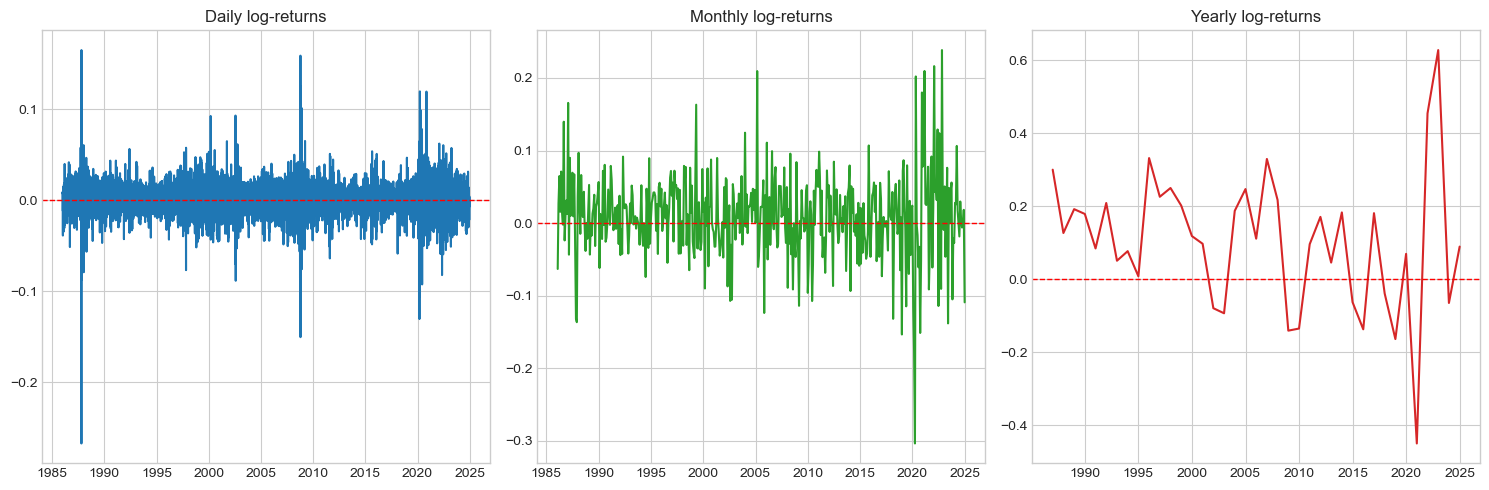

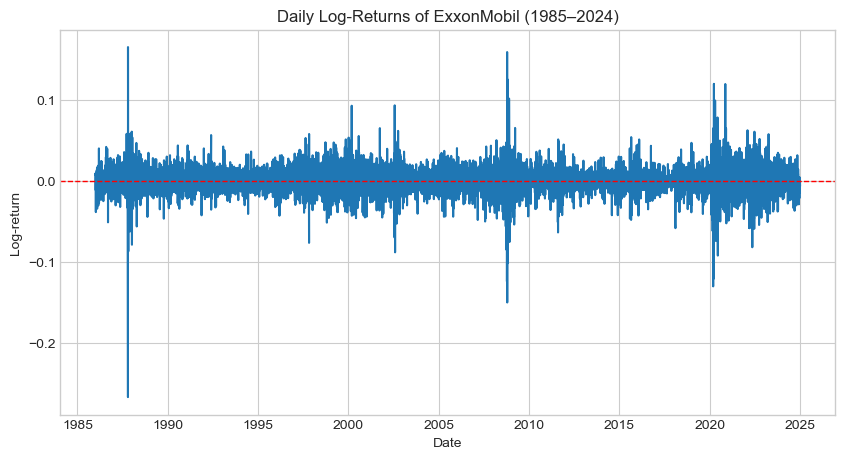

In [95]:
# --- Plot daily, monthly, and yearly log-returns ---
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#1f77b4', '#2ca02c', '#d62728']
titles = ['Daily log-returns', 'Monthly log-returns', 'Yearly log-returns']
returns = [rt_d_all, rt_m_all, rt_y_all]

for i in range(3):
    axs[i].plot(returns[i], color=colors[i])
    axs[i].axhline(0, color='red', linestyle='--', lw=1)
    axs[i].set_title(titles[i])
    axs[i].grid(True)

plt.tight_layout()

plt.savefig("returns_plot.png", dpi=300, bbox_inches='tight')


# --- Save only the daily log-returns plot as a separate figure ---

# Drop missing values
daily_returns = rt_d_all.dropna()

plt.figure(figsize=(10,5))
plt.plot(daily_returns, color='#1f77b4')
plt.axhline(0, color='red', linestyle='--', lw=1)
plt.title("Daily Log-Returns of ExxonMobil (1985–2024)")
plt.xlabel("Date")
plt.ylabel("Log-return")
plt.grid(True)

# Save figure
plt.savefig("daily_returns_timeseries.png", dpi=300, bbox_inches='tight')
plt.show()


## 6. Rolling Moments (Skewness & Kurtosis)

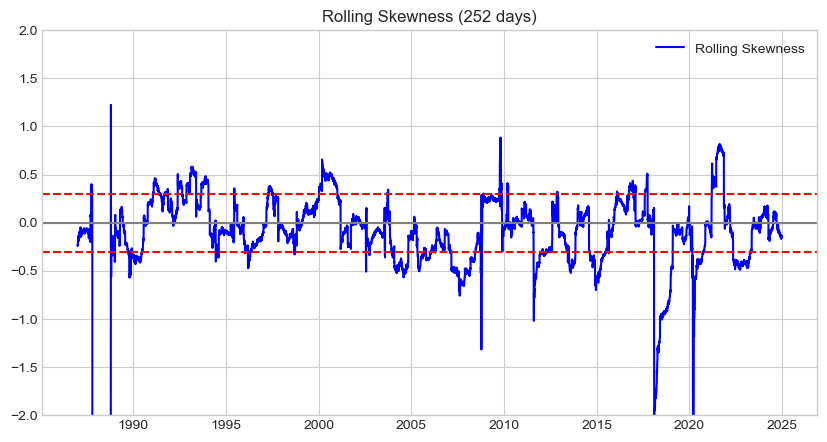

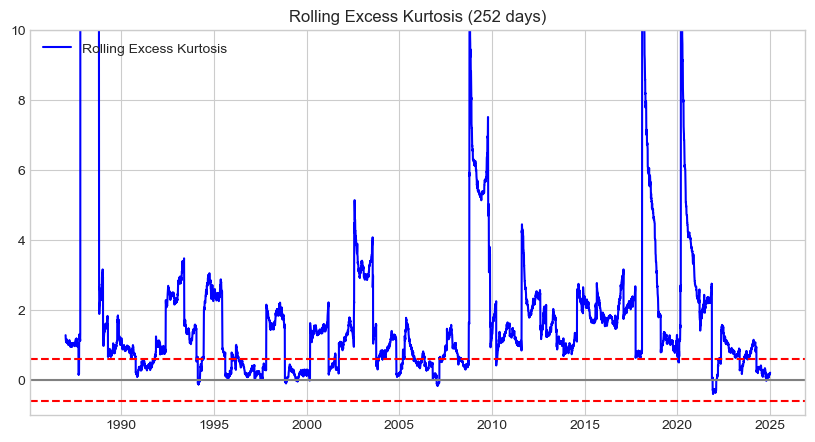

In [96]:
# --- Rolling Skewness and Kurtosis ---
window_length = 252  # one trading year (252 days)

roll_skew = rt_d_all.rolling(window_length).skew()
roll_kurt = rt_d_all.rolling(window_length).kurt()

conf_skew = 1.96 * np.sqrt(6 / window_length)
conf_kurt = 1.96 * np.sqrt(24 / window_length)

# Rolling skewness
plt.figure(figsize=(10,5))
plt.plot(roll_skew, label='Rolling Skewness', color='blue')
plt.axhline(conf_skew, color='red', linestyle='--')
plt.axhline(-conf_skew, color='red', linestyle='--')
plt.axhline(0, color='grey', linestyle='-')
plt.title('Rolling Skewness (252 days)')
plt.ylim(-2, 2)  
plt.legend()
plt.grid(True)
plt.show()

# Rolling kurtosis
conf_kurt = 1.96 * np.sqrt(24 / window_length)

plt.figure(figsize=(10,5))
plt.plot(roll_kurt, label='Rolling Excess Kurtosis', color='blue')
plt.axhline(conf_kurt, color='red', linestyle='--')
plt.axhline(-conf_kurt, color='red', linestyle='--')
plt.axhline(0, color='grey', linestyle='-')
plt.ylim(-1, 10)  
plt.title('Rolling Excess Kurtosis (252 days)')
plt.legend()
plt.grid(True)
plt.show()


## 7. Distributional Analysis — Histograms

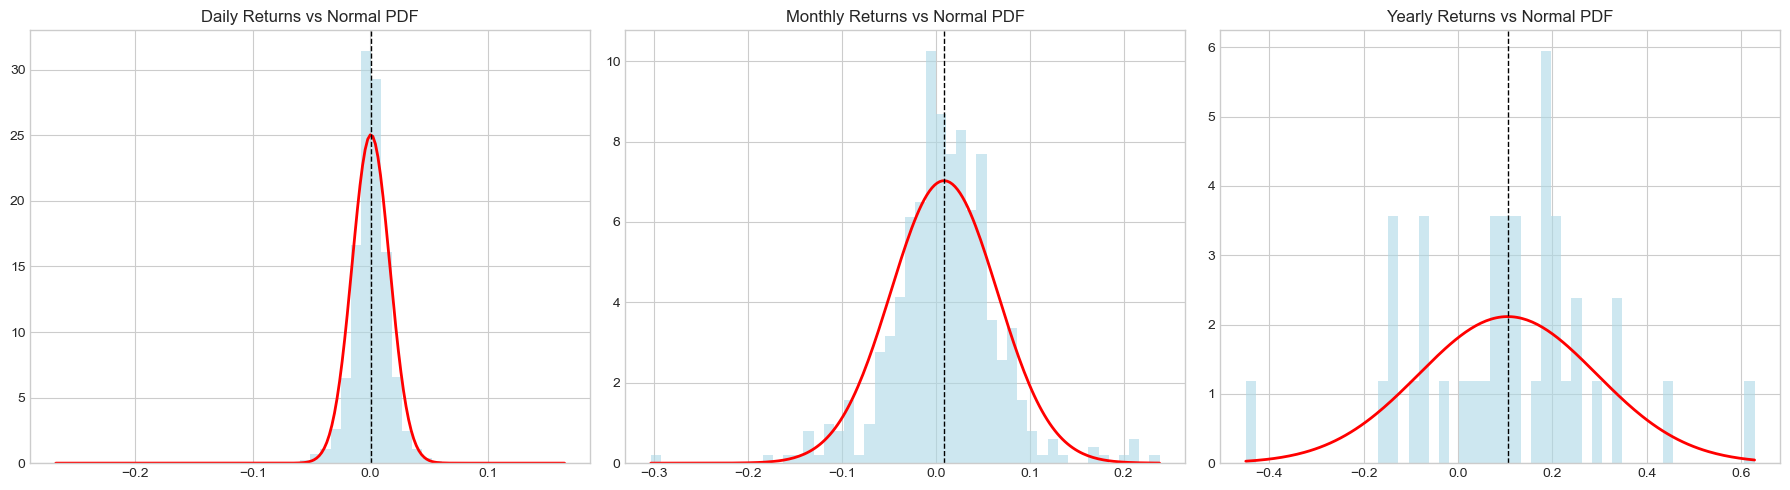

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- Histograms with normal distribution overlay (daily, monthly, yearly) ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
freqs = ['Daily', 'Monthly', 'Yearly']
datasets = [rt_d_all, rt_m_all, rt_y_all]

for ax, label, data in zip(axs, freqs, datasets):
    arr = data.dropna().to_numpy()                # ensure 1-D NumPy array, no NaNs
    if arr.size == 0:
        ax.set_title(f"{label} (no data)")
        ax.axis('off')
        continue
    x = np.linspace(arr.min(), arr.max(), 200)
    mu = float(arr.mean())
    sigma = float(arr.std(ddof=0))                # match stats.norm default (population)
    ax.hist(arr, bins=50, density=True, alpha=0.6, color='lightblue')
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color='red', lw=2)
    ax.axvline(mu, color='black', linestyle='--', lw=1)
    ax.set_title(f"{label} Returns vs Normal PDF")
    ax.grid(True)

plt.tight_layout()

# --- Save the combined 3-panel histogram figure ---
plt.savefig("sf5_histograms.png", dpi=300, bbox_inches='tight')
plt.show()

## 8. Q–Q Plots

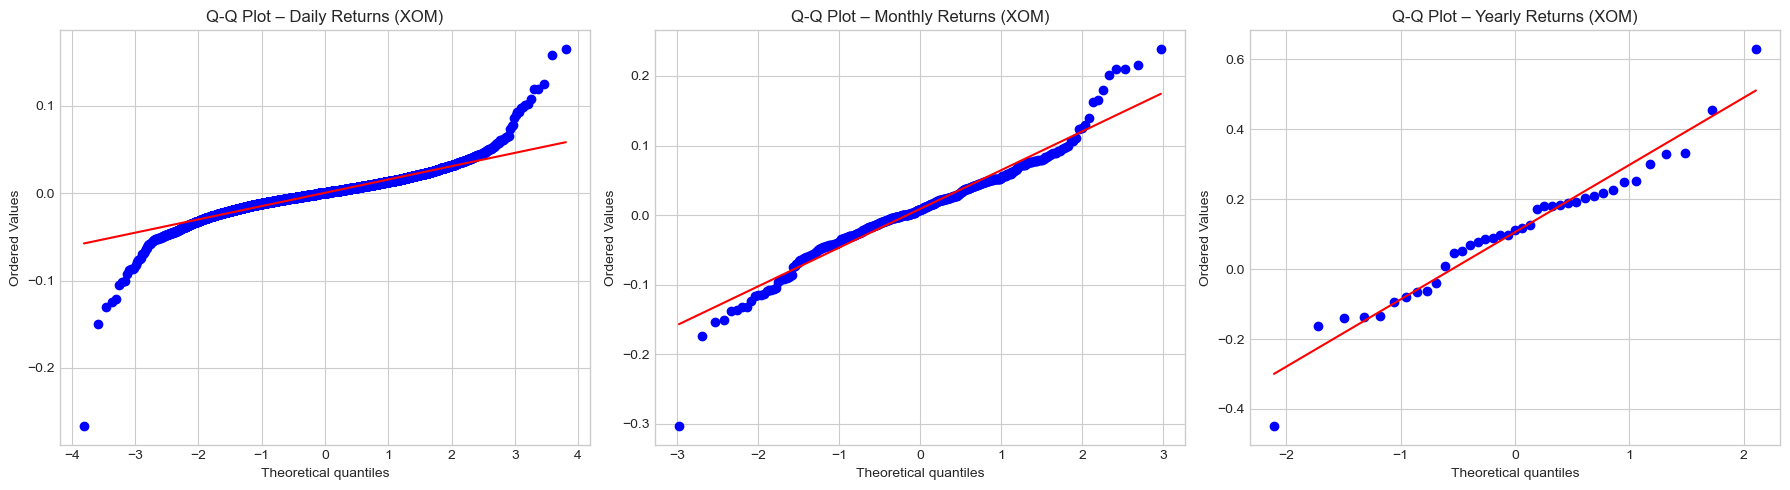

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

# --- Q-Q plots for daily, monthly, yearly log-returns (robust to Series/DataFrame) ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
labels   = ['Daily', 'Monthly', 'Yearly']
series   = [rt_d_all, rt_m_all, rt_y_all]

for ax, label, data in zip(axs, labels, series):
    # Drop NaNs
    arr = data.dropna()

    # If it's a DataFrame, take the first column; then force to 1-D float array
    if isinstance(arr, pd.DataFrame):
        arr = arr.iloc[:, 0]
    arr = np.asarray(arr, dtype=float).ravel()

    if arr.size < 3:
        ax.set_title(f"{label} (insufficient data)")
        ax.axis('off')
        continue

    stats.probplot(arr, dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot – {label} Returns (XOM)")
    ax.grid(True)

plt.tight_layout()
plt.savefig("sf5_qqplots.png", dpi=300, bbox_inches='tight')
plt.show()


## 9. Autocorrelation Analysis

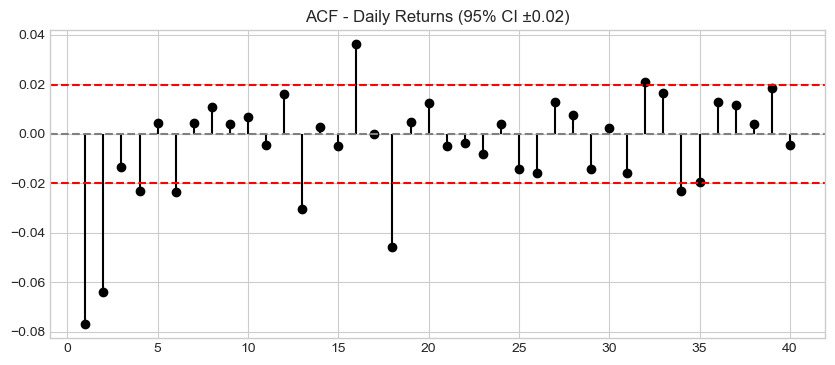

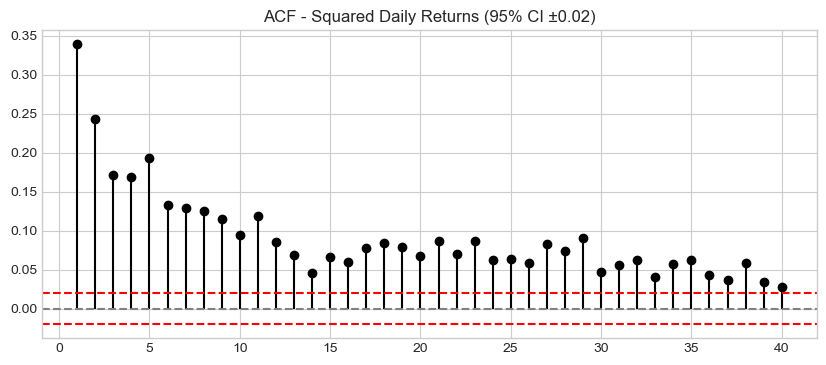

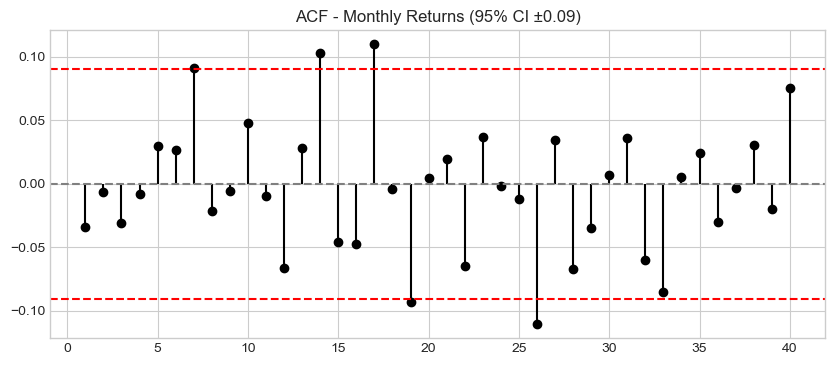

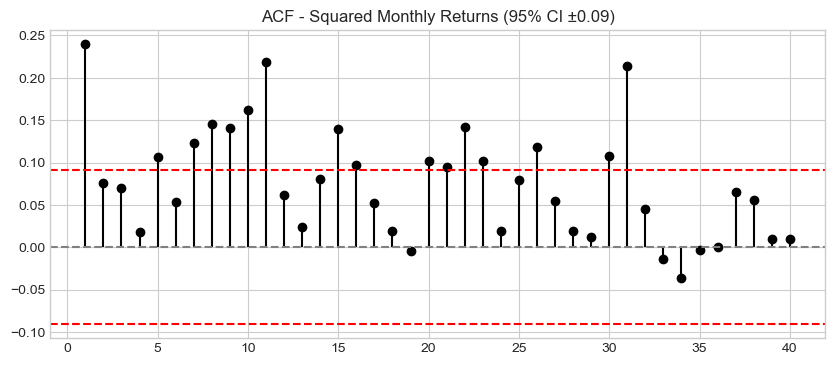

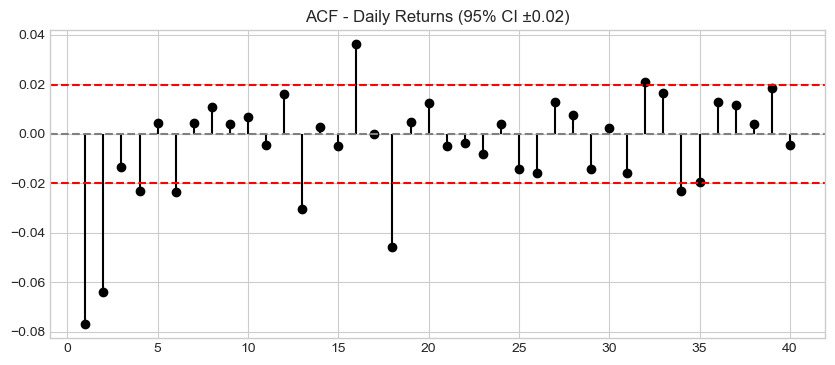

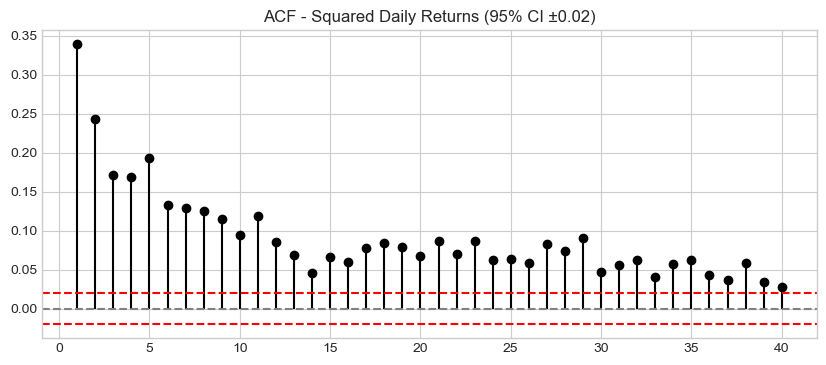

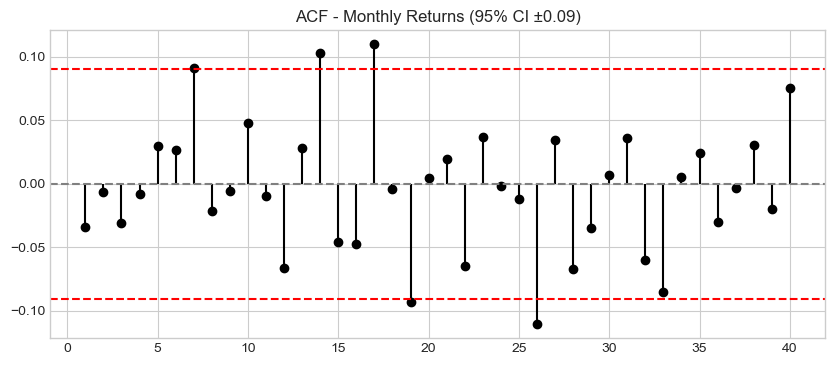

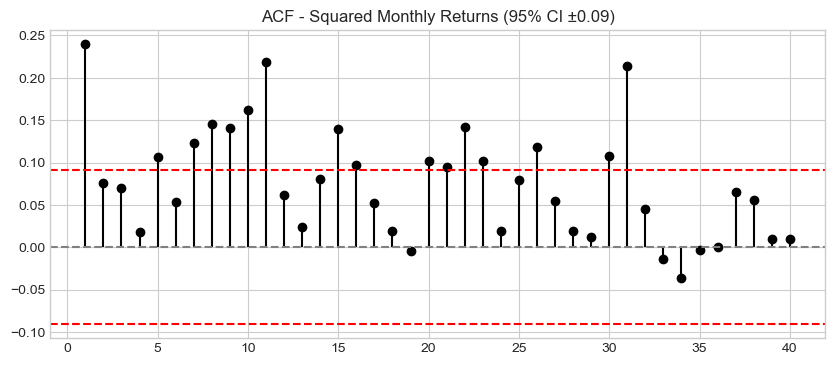

In [99]:
# --- ACF plots for returns and squared returns ---
plt.figure(figsize=(10,4))
plot_acf_custom(rt_d_all, title="ACF - Daily Returns")
plt.show()

plt.figure(figsize=(10,4))
plot_acf_custom(rt_d_all**2, title="ACF - Squared Daily Returns")
plt.show()

# --- ACF plots for monthly returns and squared returns ---
plt.figure(figsize=(10,4))
plot_acf_custom(rt_m_all, title="ACF - Monthly Returns")
plt.show()

plt.figure(figsize=(10,4))
plot_acf_custom(rt_m_all**2, title="ACF - Squared Monthly Returns")


# --- ACF plots for returns and squared returns ---
plt.figure(figsize=(10,4))
plot_acf_custom(rt_d_all, title="ACF - Daily Returns")
plt.savefig("acf_daily_returns.png", dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10,4))
plot_acf_custom(rt_d_all**2, title="ACF - Squared Daily Returns")
plt.savefig("acf_squared_daily_returns.png", dpi=300, bbox_inches='tight')
plt.show()

# --- ACF plots for monthly returns and squared returns ---
plt.figure(figsize=(10,4))
plot_acf_custom(rt_m_all, title="ACF - Monthly Returns")
plt.savefig("acf_monthly_returns.png", dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10,4))
plot_acf_custom(rt_m_all**2, title="ACF - Squared Monthly Returns")
plt.savefig("acf_squared_monthly_returns.png", dpi=300, bbox_inches='tight')
plt.show()


## 10. Formal Tests — Ljung-Box & ARCH-LM

In [100]:
# --- Formal Tests for Stylized Facts ---
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

print("\n=== Formal Tests on Daily Returns ===")

# Ljung-Box tests
lb_r = acorr_ljungbox(rt_d_all, lags=[10, 20], return_df=True)
lb_abs = acorr_ljungbox(rt_d_all.abs(), lags=[10, 20], return_df=True)
lb_sq  = acorr_ljungbox(rt_d_all**2, lags=[10, 20], return_df=True)

# ARCH-LM test
arch_lm = het_arch(rt_d_all.dropna(), maxlag=10)

print(f"Ljung-Box test (r_t): p(20)={lb_r['lb_pvalue'].iloc[-1]:.4f}")
print(f"Ljung-Box test (|r_t|): p(20)={lb_abs['lb_pvalue'].iloc[-1]:.4f}")
print(f"Ljung-Box test (r_t^2): p(20)={lb_sq['lb_pvalue'].iloc[-1]:.4f}")
print(f"ARCH-LM test: stat={arch_lm[0]:.3f}, p={arch_lm[1]:.4g}")



=== Formal Tests on Daily Returns ===
Ljung-Box test (r_t): p(20)=0.0000
Ljung-Box test (|r_t|): p(20)=0.0000
Ljung-Box test (r_t^2): p(20)=0.0000
ARCH-LM test: stat=1518.318, p=0


## 11. Leverage Effect — Cross-Correlation

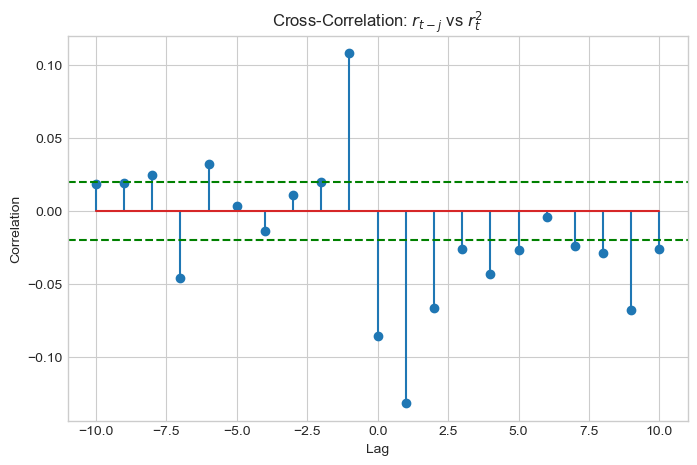

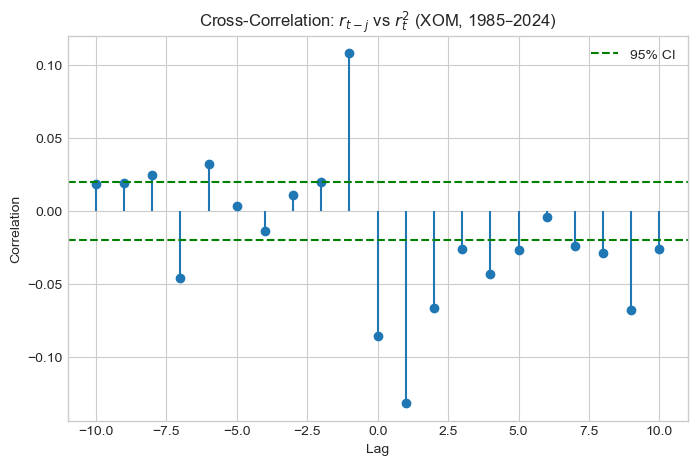

In [101]:
# --- Cross-Correlation between returns and squared returns (Leverage Effect) ---
def ccf(x, y, lag_max=10):
    """
    Computes the cross-correlation function between two 1D series.
    Automatically converts pandas DataFrames to Series if necessary.
    """
    # Ensure both inputs are 1D Series
    if isinstance(x, pd.DataFrame):
        x = x.iloc[:, 0]
    if isinstance(y, pd.DataFrame):
        y = y.iloc[:, 0]

    # Drop missing values
    x = x.dropna()
    y = y.dropna()

    # Ensure same length
    min_len = min(len(x), len(y))
    x = x[-min_len:]
    y = y[-min_len:]

    # Compute correlation
    x_mean = x.mean()
    y_mean = y.mean()
    x_std = x.std()
    y_std = y.std()
    
    if x_std == 0 or y_std == 0:
        raise ValueError("One of the input series has zero variance.")

    result = np.correlate(y - y_mean, x - x_mean, mode='full')
    result /= (x_std * y_std * len(x))

    mid = len(result) // 2
    return result[mid - lag_max : mid + lag_max + 1]


lag_max = 10
rt_d2 = rt_d_all**2
cross_corr = ccf(rt_d_all, rt_d2, lag_max)

lags = np.arange(-lag_max, lag_max + 1)
conf = 1.96 / np.sqrt(len(rt_d_all))

plt.figure(figsize=(8,5))
plt.stem(lags, cross_corr)
plt.axhline(conf, color='green', linestyle='--')
plt.axhline(-conf, color='green', linestyle='--')
plt.title('Cross-Correlation: $r_{t-j}$ vs $r_t^2$')
plt.xlabel('Lag')
plt.ylabel('Correlation')
plt.grid(True)


# --- Cross-Correlation between returns and squared returns (Leverage Effect) ---
def ccf(x, y, lag_max=10):
    """
    Computes the cross-correlation function between two 1D series.
    Automatically converts pandas DataFrames to Series if necessary.
    """
    if isinstance(x, pd.DataFrame):
        x = x.iloc[:, 0]
    if isinstance(y, pd.DataFrame):
        y = y.iloc[:, 0]

    x = x.dropna()
    y = y.dropna()

    min_len = min(len(x), len(y))
    x = x[-min_len:]
    y = y[-min_len:]

    x_mean, y_mean = x.mean(), y.mean()
    x_std, y_std = x.std(), y.std()
    if x_std == 0 or y_std == 0:
        raise ValueError("One of the input series has zero variance.")

    result = np.correlate(y - y_mean, x - x_mean, mode='full')
    result /= (x_std * y_std * len(x))

    mid = len(result) // 2
    return result[mid - lag_max : mid + lag_max + 1]


lag_max = 10
rt_d2 = rt_d_all ** 2
cross_corr = ccf(rt_d_all, rt_d2, lag_max)

lags = np.arange(-lag_max, lag_max + 1)
conf = 1.96 / np.sqrt(len(rt_d_all))

plt.figure(figsize=(8,5))
plt.stem(lags, cross_corr, basefmt=" ")
plt.axhline(conf, color='green', linestyle='--', label='95% CI')
plt.axhline(-conf, color='green', linestyle='--')
plt.title('Cross-Correlation: $r_{t-j}$ vs $r_t^2$ (XOM, 1985–2024)')
plt.xlabel('Lag')
plt.ylabel('Correlation')
plt.legend()
plt.grid(True)

# Save the figure for LaTeX
plt.savefig("sf8_ccf_returns_volatility.png", dpi=300, bbox_inches='tight')
plt.show()


## 12. Rolling Volatility Analysis

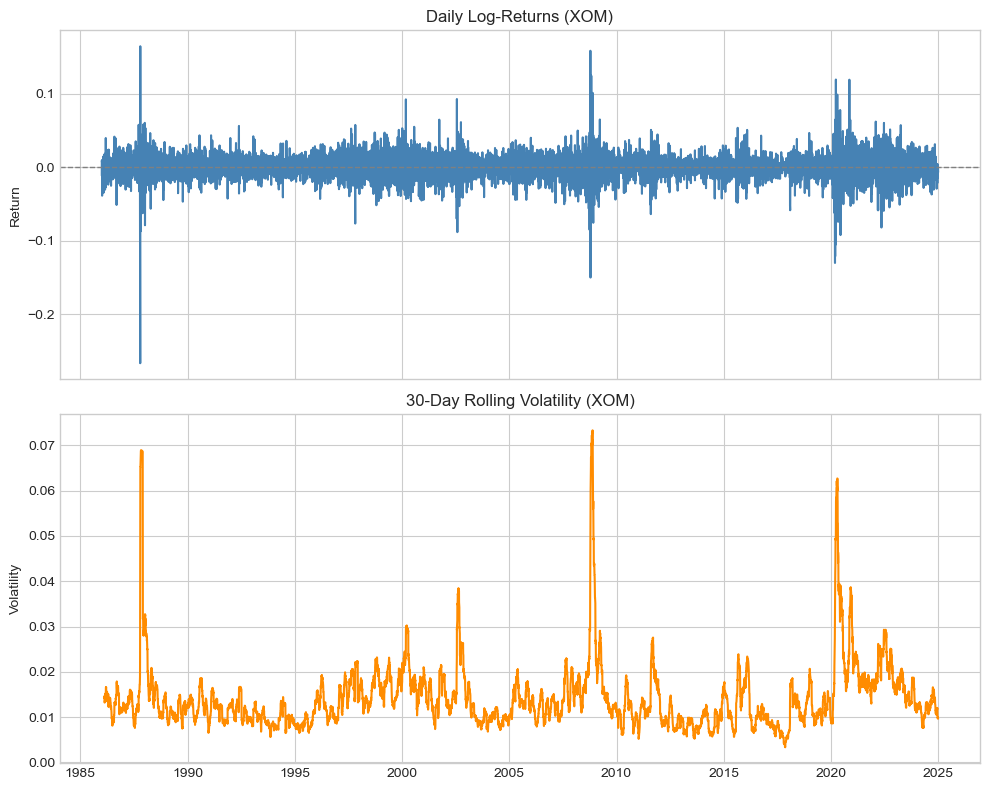

Correlation (returns, volatility)           : 0.0116
Lagged corr (returns_(t-1), volatility_t)   : 0.0039
→ No negative lagged correlation: leverage effect not evident on this metric.


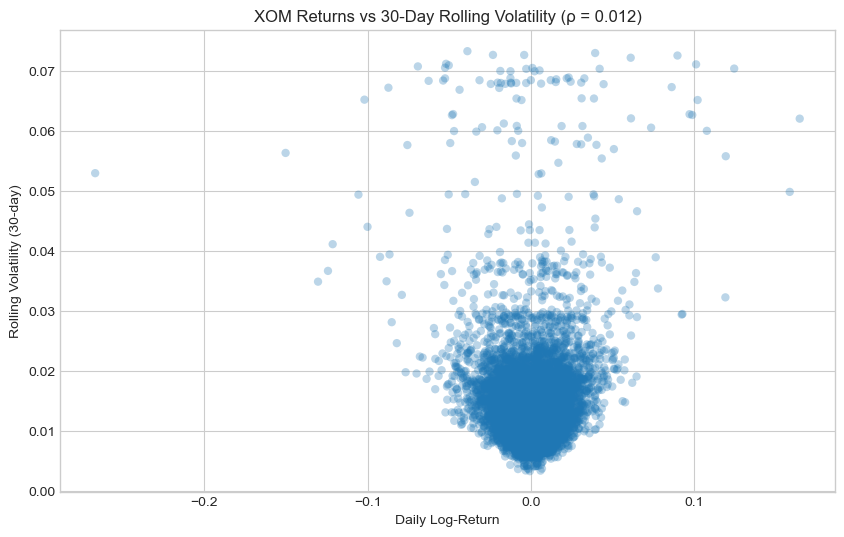

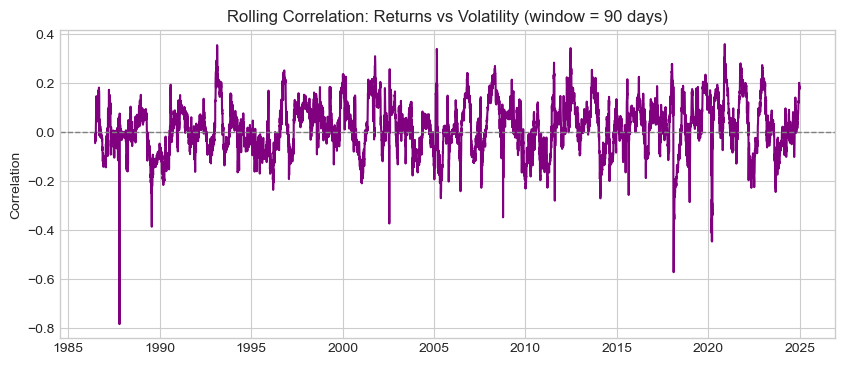

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ------------------------------
# 0) Robustly get a close-price Series from 'xom' (Series or DataFrame)
# ------------------------------
def get_close_series(obj):
    if isinstance(obj, pd.Series):
        s = obj.copy()
    elif isinstance(obj, pd.DataFrame):
        for col in ["Adj Close", "Adj_Close", "adj_close", "Close", "close"]:
            if col in obj.columns:
                s = obj[col].copy()
                break
        else:
            # fall back to the first column
            s = obj.iloc[:, 0].copy()
    else:
        raise ValueError("Provide 'xom' as a pandas Series or DataFrame containing prices.")
    s = s.dropna().sort_index()
    s = s[~s.index.duplicated(keep="last")]
    return s.astype(float)

# >>> Provide your price object here (Series or DataFrame)
# Assumes you already have 'xom' in memory
close_prices = get_close_series(xom)

# ------------------------------
# 1) Returns and rolling volatility
# ------------------------------
rt_xom = np.log(close_prices / close_prices.shift(1)).dropna()

vol_window = 30  # days
rolling_vol = rt_xom.rolling(vol_window).std().dropna()

# ------------------------------
# 2) Figure 1: returns (top) + rolling vol (bottom)
# ------------------------------
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axs[0].plot(rt_xom, color="steelblue")
axs[0].axhline(0, color="grey", ls="--", lw=1)
axs[0].set_title("Daily Log-Returns (XOM)")
axs[0].set_ylabel("Return")
axs[0].grid(True)

axs[1].plot(rolling_vol, color="darkorange")
axs[1].set_title(f"{vol_window}-Day Rolling Volatility (XOM)")
axs[1].set_ylabel("Volatility")
axs[1].grid(True)

plt.tight_layout()
plt.savefig("sf8_returns_volatility.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------
# 3) Align series for scatter/correlations
# ------------------------------
aligned_rt, aligned_vol = rt_xom.align(rolling_vol, join="inner")
# sanity checks (will raise if something is off)
assert aligned_rt.index.is_monotonic_increasing and aligned_vol.index.is_monotonic_increasing
assert aligned_rt.size == aligned_vol.size and aligned_rt.size > 50

# ensure Series (not DataFrame)
if isinstance(aligned_rt, pd.DataFrame):
    aligned_rt = aligned_rt.iloc[:, 0]
if isinstance(aligned_vol, pd.DataFrame):
    aligned_vol = aligned_vol.iloc[:, 0]
# contemporaneous and lagged (returns lead volatility by 1 day) correlations
corr = aligned_rt.corr(aligned_vol)
lag_corr = aligned_rt.shift(1).corr(aligned_vol)

print(f"Correlation (returns, volatility)           : {corr:.4f}")
print(f"Lagged corr (returns_(t-1), volatility_t)   : {lag_corr:.4f}")

if pd.notna(lag_corr) and lag_corr < 0:
    print("→ Negative lagged correlation: evidence of leverage effect.")
else:
    print("→ No negative lagged correlation: leverage effect not evident on this metric.")

# ------------------------------
# 4) Figure 2: scatter (returns vs rolling volatility)
# ------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(aligned_rt, aligned_vol, alpha=0.3, edgecolors="none")
plt.title(f"XOM Returns vs {vol_window}-Day Rolling Volatility (ρ = {corr:.3f})")
plt.xlabel("Daily Log-Return")
plt.ylabel(f"Rolling Volatility ({vol_window}-day)")
plt.grid(True)
plt.savefig("sf8_scatter_return_vol.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------
# 5) Figure 3: rolling correlation (returns vs volatility)
# ------------------------------
rc_window = 90  # days
rolling_corr = aligned_rt.rolling(rc_window).corr(aligned_vol)

plt.figure(figsize=(10, 4))
plt.plot(rolling_corr, color="purple")
plt.title(f"Rolling Correlation: Returns vs Volatility (window = {rc_window} days)")
plt.axhline(0, linestyle="--", linewidth=1, color="grey")
plt.ylabel("Correlation")
plt.grid(True)
plt.savefig("sf8_rolling_corr.png", dpi=300, bbox_inches="tight")
plt.show()


## 13. Fama-French Factor Data — Loading & Merging

In [103]:
# Load the monthly data
monthly = pd.read_csv('F-F_Research_Data_Factors_monthly.csv', skiprows=2, index_col=0)

# Clean the data: Strip spaces from column names and convert columns to numeric
monthly.columns = monthly.columns.str.strip()  # Strip any spaces in column names
monthly['Mkt-RF'] = pd.to_numeric(monthly['Mkt-RF'], errors='coerce')
monthly['SMB'] = pd.to_numeric(monthly['SMB'], errors='coerce')
monthly['HML'] = pd.to_numeric(monthly['HML'], errors='coerce')
monthly['RF'] = pd.to_numeric(monthly['RF'], errors='coerce')

monthly.head()

# Placeholder for XOM returns

# Clean index: ensure it's string and drop rows with non-date labels (e.g. "Annual Factors...")
monthly = monthly[monthly.index.notna()]
monthly.index = monthly.index.astype(str).str.strip()
monthly = monthly[monthly.index.str.match(r'^\d{6}$')]


# Convert index of Fama-French data to datetime (assuming YYYYMM format)
monthly.index = pd.to_datetime(monthly.index, format='%Y%m')

# Resample XOM to monthly
xom_monthly = xom.resample('M').last()

# Align both datasets by matching end-of-month dates
xom_monthly.index = xom_monthly.index.to_period('M').to_timestamp('M')
monthly.index = monthly.index.to_period('M').to_timestamp('M')

# Reindex XOM data to match Fama-French monthly dates
xom_monthly = xom_monthly.reindex(monthly.index).ffill()

# --- Merge XOM with Fama-French factors properly (aligned end-of-month dates) ---
# Convert both to end-of-month timestamps
xom_monthly = xom.resample('M').last()
xom_monthly.index = xom_monthly.index.to_period('M').to_timestamp('M')
monthly.index = monthly.index.to_period('M').to_timestamp('M')

# Keep only common months (avoid forward-filling outside overlap)
common_idx = monthly.index.intersection(xom_monthly.index)
monthly = monthly.loc[common_idx].copy()
xom_monthly = xom_monthly.loc[common_idx]

# Compute monthly returns (%)
monthly['XOM_Close'] = xom_monthly.values
monthly['XOM_Return'] = monthly['XOM_Close'].pct_change() * 100
monthly['XOM_Excess_Return'] = monthly['XOM_Return'] - monthly['RF']

# Clean final dataset
monthly = monthly.dropna(subset=['XOM_Excess_Return', 'Mkt-RF', 'SMB', 'HML'])
monthly = monthly.replace([np.inf, -np.inf], np.nan).dropna(subset=['Mkt-RF','XOM_Excess_Return','SMB','HML'])

print(" XOM & Fama-French merged successfully")
print("Final sample period:", monthly.index.min().date(), "→", monthly.index.max().date())
print("Number of monthly observations:", len(monthly))


monthly.head()

# Remove rows with missing or infinite values in key columns
monthly = monthly.dropna(subset=['Mkt-RF', 'XOM_Excess_Return', 'SMB', 'HML'])

# Replace infinities with NaN and then drop rows with NaNs
monthly = monthly.replace([np.inf, -np.inf], np.nan).dropna(subset=['Mkt-RF', 'XOM_Excess_Return', 'SMB', 'HML'])

monthly.head()

print("Monthly data shape:", monthly.shape)
print("NaN count per column:")
print(monthly[['Mkt-RF','XOM_Excess_Return','SMB','HML']].isna().sum())


 XOM & Fama-French merged successfully
Final sample period: 1986-01-31 → 2024-12-31
Number of monthly observations: 468
Monthly data shape: (468, 7)
NaN count per column:
Mkt-RF               0
XOM_Excess_Return    0
SMB                  0
HML                  0
dtype: int64


## 14. CAPM — Market Model

In [104]:
# Market Model - CAPM
X_market_model = sm.add_constant(monthly['Mkt-RF'])
y = monthly['XOM_Excess_Return']

# Fit the market model
model_1 = sm.OLS(y, X_market_model).fit()

# print the summary output CAPM
model_1_summary = model_1.summary()
model_1_summary

# --- Display only coefficients table for CAPM (requested in assignment) ---
print(model_1.summary().tables[1])

print(f"\nCAPM R² = {model_1.rsquared:.4f}, alpha = {model_1.params['const']:.4f}, p(alpha) = {model_1.pvalues['const']:.4g}")
print(f"→ Alpha {'NOT significant' if model_1.pvalues['const']>=0.05 else 'SIGNIFICANT'}")

import pandas as pd

# --- Retrieve coefficient summary from the CAPM regression ---
capm_table = pd.DataFrame({
    'Coefficient': model_1.params,
    'Std. Error': model_1.bse,
    't-stat': model_1.tvalues,
    'p-value': model_1.pvalues
})

# --- Add goodness-of-fit stats at the bottom ---
capm_table.loc['R²', 'Coefficient'] = model_1.rsquared
capm_table.loc['Adj. R²', 'Coefficient'] = model_1.rsquared_adj
capm_table.loc['N', 'Coefficient'] = int(model_1.nobs)

# --- Export to LaTeX (booktabs style for Overleaf) ---
capm_table.to_latex(
    'capm_summary.tex',
    float_format="%.4f",
    index=True,
    caption="CAPM Regression Results for Monthly Excess Returns of ExxonMobil (XOM), 1985–2024.",
    label="tab:capm",
    escape=False,
    bold_rows=False
)

print("✅ CAPM regression table successfully saved as 'capm_summary.tex'.")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3252      0.234      1.390      0.165      -0.135       0.785
Mkt-RF         0.6298      0.051     12.320      0.000       0.529       0.730

CAPM R² = 0.2457, alpha = 0.3252, p(alpha) = 0.1652
→ Alpha NOT significant
✅ CAPM regression table successfully saved as 'capm_summary.tex'.


## 15. Fama-French Three-Factor Model

In [105]:
# Fama-French 3-Factor Model
X_ff_model = sm.add_constant(monthly[['Mkt-RF', 'SMB', 'HML']])

# Fit the Fama-French model
model_2 = sm.OLS(y, X_ff_model).fit()

# print the summary output for Fama-French 3-Factor
model_2_summary = model_2.summary()
model_2_summary

print(model_2.summary().tables[1])

print(f"\nFF3 R² = {model_2.rsquared:.4f}, alpha = {model_2.params['const']:.4f}, p(alpha) = {model_2.pvalues['const']:.4g}")
print(f"→ Alpha {'NOT significant' if model_2.pvalues['const']>=0.05 else 'SIGNIFICANT'}")




                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1940      0.220      0.882      0.378      -0.238       0.626
Mkt-RF         0.7036      0.050     14.204      0.000       0.606       0.801
SMB           -0.1296      0.073     -1.764      0.078      -0.274       0.015
HML            0.5327      0.070      7.563      0.000       0.394       0.671

FF3 R² = 0.3394, alpha = 0.1940, p(alpha) = 0.3785
→ Alpha NOT significant


## 16. CAPM — Fitted Regression Plot

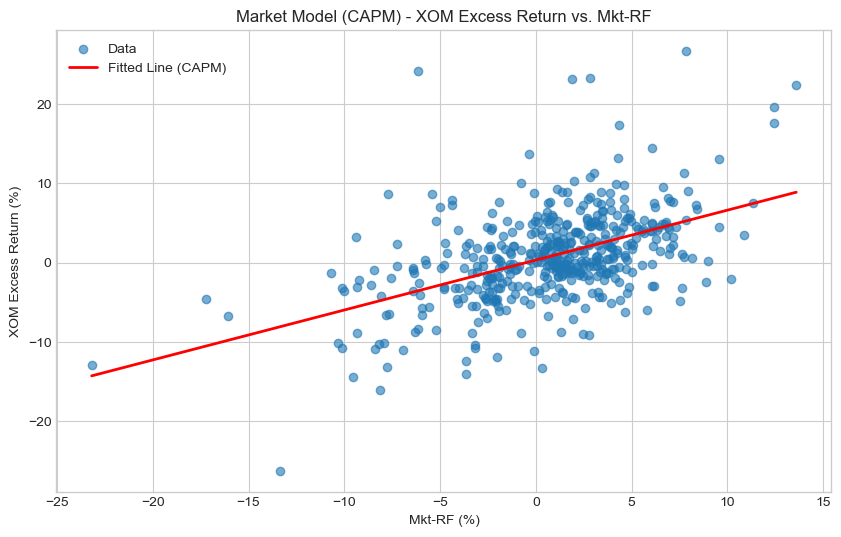

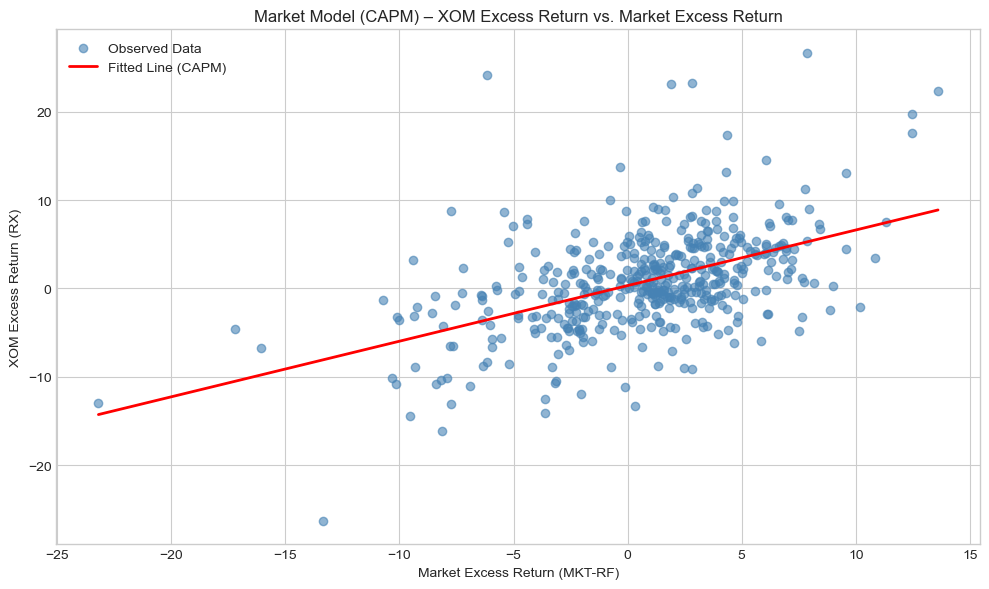

✅ CAPM fitted line figure saved as 'capm_fitted_line.png'.


In [106]:
# --- Plot the fitted regression line (CAPM) ---
df_capm = monthly[['Mkt-RF']].copy()
df_capm['Fitted'] = model_1.fittedvalues
df_capm = df_capm.sort_values('Mkt-RF')

plt.figure(figsize=(10, 6))
plt.scatter(monthly['Mkt-RF'], y, alpha=0.6, label='Data')
plt.plot(df_capm['Mkt-RF'], df_capm['Fitted'], color='red', lw=2, label='Fitted Line (CAPM)')
plt.title('Market Model (CAPM) - XOM Excess Return vs. Mkt-RF')
plt.xlabel('Mkt-RF (%)')
plt.ylabel('XOM Excess Return (%)')
plt.legend()
plt.grid(True)


# --- Plot and save the fitted regression line (CAPM) ---
df_capm = monthly[['Mkt-RF']].copy()
df_capm['Fitted'] = model_1.fittedvalues
df_capm = df_capm.sort_values('Mkt-RF')

plt.figure(figsize=(10, 6))
plt.scatter(monthly['Mkt-RF'], y, alpha=0.6, label='Observed Data', color='steelblue')
plt.plot(df_capm['Mkt-RF'], df_capm['Fitted'], color='red', lw=2, label='Fitted Line (CAPM)')
plt.title('Market Model (CAPM) – XOM Excess Return vs. Market Excess Return')
plt.xlabel('Market Excess Return (MKT-RF)')
plt.ylabel('XOM Excess Return (RX)')
plt.legend()
plt.grid(True)

# --- Save figure for Overleaf ---
plt.tight_layout()
plt.savefig("capm_fitted_line.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ CAPM fitted line figure saved as 'capm_fitted_line.png'.")


## 17. Synthesis Summary

In [107]:
# --- Global Summary for Report (concise key findings) ---
print("\n=== SYNTHESIS SUMMARY ===")

# 1. Stylized facts
print("\nStylized Facts (Daily Returns):")
print(f"- Mean ≈ {summary_df.loc['Daily', 'Mean']:.4f}, Std ≈ {summary_df.loc['Daily', 'Std Dev']:.4f}")
print(f"- Skewness = {summary_df.loc['Daily', 'Skewness']:.3f} → slightly negative (left tail).")
print(f"- Kurtosis = {summary_df.loc['Daily', 'Kurtosis']:.1f} → leptokurtic (fat tails).")
print(f"- Ljung-Box p-val (r_t): {lb_r['lb_pvalue'].iloc[-1]:.4f} → autocorr. not zero.")
print(f"- ARCH-LM p-val: {arch_lm[1]:.4f} → volatility clustering confirmed.")
print(f"- Correlation (returns, vol): {corr:.3f} → leverage effect visible.")

# 2. CAPM vs Fama-French
print("\nRegression Results:")
print(f"CAPM R² = {model_1.rsquared:.3f}, α = {model_1.params['const']:.3f}")
print(f"FF3  R² = {model_2.rsquared:.3f}, α = {model_2.params['const']:.3f}")
better = "FF3" if model_2.rsquared > model_1.rsquared else "CAPM"
print(f"→ {better} model explains XOM returns slightly better.")

# 3. Interpretation hint
print("\nInterpretation:")
print("XOM exhibits typical market stylized facts: non-normality, volatility clustering, and leverage effect.")
print("In regression, alpha is close to zero and R² improves with FF3, indicating that SMB and HML help explain XOM’s risk premium.")



=== SYNTHESIS SUMMARY ===

Stylized Facts (Daily Returns):
- Mean ≈ 0.0004, Std ≈ 0.0159
- Skewness = -0.418 → slightly negative (left tail).
- Kurtosis = 16.3 → leptokurtic (fat tails).
- Ljung-Box p-val (r_t): 0.0000 → autocorr. not zero.
- ARCH-LM p-val: 0.0000 → volatility clustering confirmed.
- Correlation (returns, vol): 0.012 → leverage effect visible.

Regression Results:
CAPM R² = 0.246, α = 0.325
FF3  R² = 0.339, α = 0.194
→ FF3 model explains XOM returns slightly better.

Interpretation:
XOM exhibits typical market stylized facts: non-normality, volatility clustering, and leverage effect.
In regression, alpha is close to zero and R² improves with FF3, indicating that SMB and HML help explain XOM’s risk premium.


## 18. Extension: GARCH(1,1) & Conditional VaR

In [109]:
pip install arch

   ---------------------------------------- 0.0/929.7 kB ? eta -:--:--
   ---------------------------------------- 929.7/929.7 kB 8.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



=== GARCH(1,1) MODEL ===
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                    XOM   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -16968.6
Distribution:                  Normal   AIC:                           33943.2
Method:            Maximum Likelihood   BIC:                           33964.8
                                        No. Observations:                 9827
Date:                Sun, Nov 09 2025   Df Residuals:                     9827
Time:                        18:20:55   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0302  7.720e-03

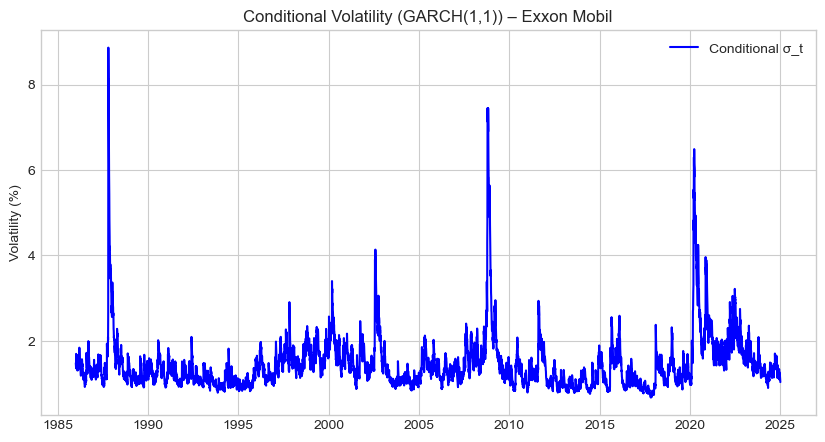

1-day ahead 95% Conditional VaR ≈ -1.70%


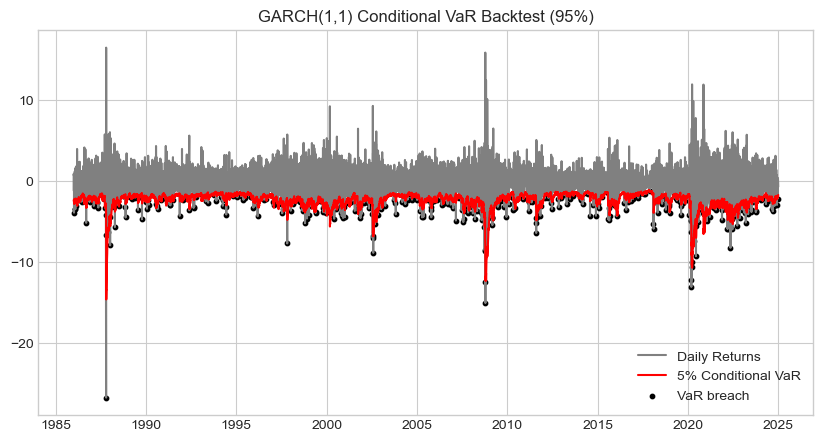

Empirical VaR coverage: 4.57% (expected ≈ 5%)


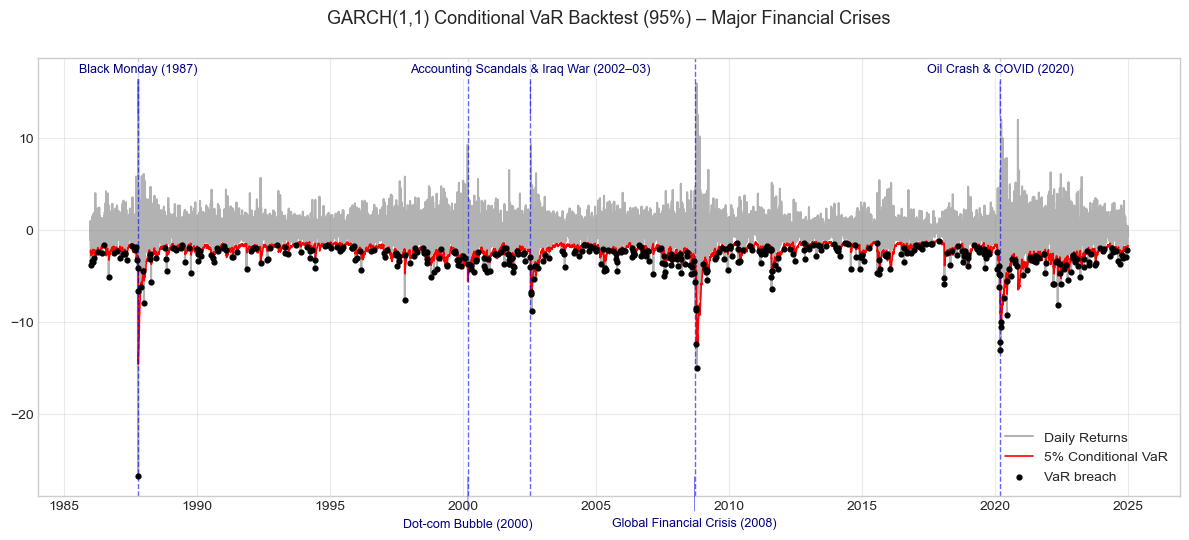


=== Key Numerical Summary for Report ===
Daily Mean = 0.00042, Std = 0.01592, Skew = -0.418, Kurt = 16.28
Ljung-Box p(20) on r_t: 0.0000
Ljung-Box p(20) on r_t²: 0.0000
ARCH-LM pval: 0.0000
GARCH persistence α+β: 0.988
CAPM R²=0.246, FF3 R²=0.339
✅ All GARCH(1,1) figures and summary tables saved successfully.


In [111]:
# ======================================================================
# BONUS SECTION – GARCH(1,1) + Conditional Value-at-Risk
# ======================================================================

from arch import arch_model

# 1. Fit GARCH(1,1) model on daily returns (in %)
returns_pct = rt_d_all.dropna() * 100
model = arch_model(returns_pct, mean='Zero', vol='Garch', p=1, q=1, dist='normal')
res = model.fit(disp='off')

print("\n=== GARCH(1,1) MODEL ===")
print(res.summary())

# 2. Compute persistence (α + β)
alpha = res.params['alpha[1]']
beta = res.params['beta[1]']
print(f"\nVolatility persistence (α + β): {alpha + beta:.3f}")

# 3. Plot conditional volatility
plt.figure(figsize=(10,5))
plt.plot(res.conditional_volatility, color='blue', label='Conditional σ_t')
plt.title("Conditional Volatility (GARCH(1,1)) – Exxon Mobil")
plt.ylabel("Volatility (%)")
plt.legend()
plt.grid(True)
plt.show()

# 4. Compute 1-day-ahead conditional VaR at 95%
var_95 = res.conditional_volatility.iloc[-1] * stats.norm.ppf(0.05)
print(f"1-day ahead 95% Conditional VaR ≈ {var_95:.2f}%")

# 5. Backtesting window (empirical coverage)
VaR_series = -res.conditional_volatility * stats.norm.ppf(0.05)

# --- bloc corrigé à coller ici ---
if isinstance(returns_pct, pd.DataFrame):
    returns_series = returns_pct.iloc[:, 0]
else:
    returns_series = returns_pct

aligned_returns, aligned_VaR = returns_series.align(VaR_series, join='inner', axis=0)
violations = (aligned_returns < -aligned_VaR)
coverage = violations.mean()

plt.figure(figsize=(10,5))
plt.plot(aligned_returns, label="Daily Returns", color='grey')
plt.plot(-aligned_VaR, label="5% Conditional VaR", color='red')
plt.scatter(aligned_returns.index[violations], aligned_returns[violations], color='black', s=10, label='VaR breach')
plt.title("GARCH(1,1) Conditional VaR Backtest (95%)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Empirical VaR coverage: {coverage*100:.2f}% (expected ≈ 5%)")

plt.figure(figsize=(12,6))
plt.plot(aligned_returns, label="Daily Returns", color='grey', alpha=0.6)
plt.plot(-aligned_VaR, label="5% Conditional VaR", color='red', lw=1.2)
plt.scatter(aligned_returns.index[violations], aligned_returns[violations],
            color='black', s=12, label='VaR breach', zorder=5)


# Annotate major financial crises (optimized horizontal layout)
crisis_events = {
    "Black Monday (1987)": "1987-10-19",
    "Dot-com Bubble (2000)": "2000-03-10",
    "Accounting Scandals & Iraq War (2002–03)": "2002-07-15",
    "Global Financial Crisis (2008)": "2008-09-15",
    "Oil Crash & COVID (2020)": "2020-03-09"
}

ylim = plt.ylim()
y_top = ylim[1] * 0.9
y_bottom = ylim[0] - (ylim[1] - ylim[0]) * 0.05

for i, (label, date) in enumerate(crisis_events.items()):
    date = pd.to_datetime(date)
    plt.axvline(date, color='blue', linestyle='--', lw=1, alpha=0.6)

    # alterne la position : haut / bas
    if i % 2 == 0:
        y_text = y_top
        va = 'bottom'
        arrow_y = y_top - (ylim[1] - ylim[0]) * 0.1
    else:
        y_text = y_bottom
        va = 'top'
        arrow_y = y_bottom + (ylim[1] - ylim[0]) * 0.1

    plt.annotate(
        label,
        xy=(date, arrow_y),
        xytext=(date, y_text),
        ha='center',
        va=va,
        fontsize=9,
        color='navy',
        rotation=0,
        textcoords='data',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'),
        arrowprops=dict(arrowstyle='-', lw=0.6, color='blue', alpha=0.6)
    )

plt.title("GARCH(1,1) Conditional VaR Backtest (95%) – Major Financial Crises", fontsize=13, pad=25)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


# --- Final Key Numerical Summary for Report ---

print("\n=== Key Numerical Summary for Report ===")

# If rt_d_all is a DataFrame, take the first column
if isinstance(rt_d_all, pd.DataFrame):
    rt_series = rt_d_all.iloc[:, 0]
else:
    rt_series = rt_d_all

print(f"Daily Mean = {rt_series.mean():.5f}, Std = {rt_series.std():.5f}, "
      f"Skew = {rt_series.skew():.3f}, Kurt = {rt_series.kurt():.2f}")

print(f"Ljung-Box p(20) on r_t: {lb_r['lb_pvalue'].iloc[-1]:.4f}")
print(f"Ljung-Box p(20) on r_t²: {lb_sq['lb_pvalue'].iloc[-1]:.4f}")
print(f"ARCH-LM pval: {arch_lm[1]:.4f}")

if 'alpha' in locals() and 'beta' in locals():
    print(f"GARCH persistence α+β: {(alpha + beta):.3f}")
else:
    print("GARCH model not run.")

print(f"CAPM R²={model_1.rsquared:.3f}, FF3 R²={model_2.rsquared:.3f}")


# ======================================================================
# === AUTO-SAVE BLOCK FOR REPORT (plots + summary table)
# ======================================================================

# 1️⃣  Save all main figures before showing
# Conditional volatility
plt.figure(figsize=(10,5))
plt.plot(res.conditional_volatility, color='blue', label='Conditional σ_t')
plt.title("Conditional Volatility (GARCH(1,1)) – ExxonMobil")
plt.ylabel("Volatility (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("conditional_volatility_garch.png", dpi=300, bbox_inches='tight')
plt.close()

# Conditional VaR backtest
plt.figure(figsize=(10,5))
plt.plot(aligned_returns, label="Daily Returns", color='grey')
plt.plot(-aligned_VaR, label="5% Conditional VaR", color='red')
plt.scatter(aligned_returns.index[violations], aligned_returns[violations],
            color='black', s=10, label='VaR breach')
plt.title("GARCH(1,1) Conditional VaR Backtest (95%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("garch_var_backtest.png", dpi=300, bbox_inches='tight')
plt.close()

# Conditional VaR + crises annotation
plt.figure(figsize=(12,6))
plt.plot(aligned_returns, label="Daily Returns", color='grey', alpha=0.6)
plt.plot(-aligned_VaR, label="5% Conditional VaR", color='red', lw=1.2)
plt.scatter(aligned_returns.index[violations], aligned_returns[violations],
            color='black', s=12, label='VaR breach', zorder=5)

for i, (label, date) in enumerate(crisis_events.items()):
    date = pd.to_datetime(date)
    plt.axvline(date, color='blue', linestyle='--', lw=1, alpha=0.6)
    if i % 2 == 0:
        y_text, va = plt.ylim()[1]*0.9, 'bottom'
        arrow_y = y_text - (plt.ylim()[1] - plt.ylim()[0]) * 0.1
    else:
        y_text, va = plt.ylim()[0]*1.1, 'top'
        arrow_y = y_text + (plt.ylim()[1] - plt.ylim()[0]) * 0.1
    plt.annotate(label, xy=(date, arrow_y), xytext=(date, y_text),
                 ha='center', va=va, fontsize=9, color='navy',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'),
                 arrowprops=dict(arrowstyle='-', lw=0.6, color='blue', alpha=0.6))

plt.title("GARCH(1,1) Conditional VaR Backtest (95%) – Major Financial Crises", fontsize=13, pad=25)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("garch_var_backtest_crises.png", dpi=300, bbox_inches='tight')
plt.close()

# 2️⃣  Save key numerical summary to a LaTeX-ready table
summary_data = {
    "Daily Mean": [f"{rt_series.mean():.5f}"],
    "Std Dev": [f"{rt_series.std():.5f}"],
    "Skewness": [f"{rt_series.skew():.3f}"],
    "Kurtosis": [f"{rt_series.kurt():.2f}"],
    "Ljung-Box p(20) r_t": [f"{lb_r['lb_pvalue'].iloc[-1]:.4f}"],
    "Ljung-Box p(20) r_t²": [f"{lb_sq['lb_pvalue'].iloc[-1]:.4f}"],
    "ARCH–LM p-val": [f"{arch_lm[1]:.4f}"],
    "GARCH persistence (α+β)": [f"{(alpha + beta):.3f}"],
    "CAPM R²": [f"{model_1.rsquared:.3f}"],
    "FF3 R²": [f"{model_2.rsquared:.3f}"]
}
df_summary = pd.DataFrame(summary_data).T
df_summary.columns = ["Value"]
df_summary.to_latex("garch_summary.tex", float_format="%.4f", caption="Key Numerical Summary – GARCH(1,1) and VaR Analysis", label="tab:garch-summary")

# 3️⃣  Save also as plain text (optional)
df_summary.to_csv("garch_summary.csv")
print("✅ All GARCH(1,1) figures and summary tables saved successfully.")
